SAE 2.04
TD4
Equipe 5 : DURAN Kalvin, EAR Francois, EL KANIZI Loubna, ORDAS Ethan, RAOUX Matheo

In [21]:
#importation des bibliothèques nécessaires aux graphiques
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Affiche le dossier de travail"
print("Dossier de travail actuel :")
print(os.getcwd())
#os.chdir("../SAE204_tests/")
#Affiche la liste des fichiers dans le dossier de travail pour s'assurer d'être au bon endroit
print("\nFichiers et dossiers détectés ici :")
print(os.listdir())

Dossier de travail actuel :
C:\Users\Kalvin\SAE204_tests

Fichiers et dossiers détectés ici :
['.ipynb_checkpoints', 'faker_output_v3', 'faker_output_v3.zip', 'faker_script_2.py', 'graphique1_grades.png', 'graphique2_types_organisation.png', 'graphique3_types_aliment.png', 'Kalvin_Jupyter_Notebook-checkpoint-Copy1.ipynb', 'Kalvin_Jupyter_Notebook-checkpoint.ipynb', 'TD4 _Equipe 5 _SAE204-checkpoint.ipynb', 'test']


count       10.000000
mean     10000.000000
std       9422.171017
min        987.000000
25%       3272.000000
50%       7057.000000
75%      13792.500000
max      30491.000000
dtype: float64


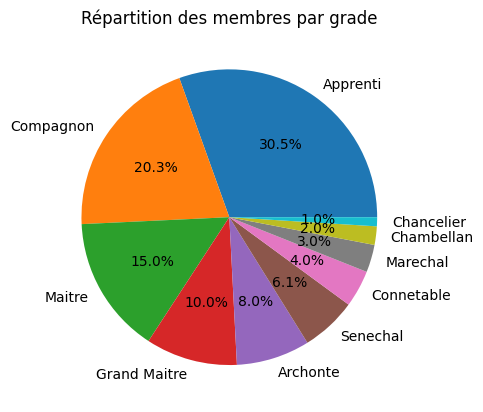

In [22]:
# Chargement des CSV nécessaires aux graphiques
membres     = pd.read_csv("faker_output_v3/Membre.csv")
grades      = pd.read_csv("faker_output_v3/grade.csv")
composant  = pd.read_csv("faker_output_v3/composant.csv")
organisation = pd.read_csv("faker_output_v3/organisation.csv")

# Création d'un tableau qui contient les infos des membres et les libellés des grades
df = membres.merge(grades, on="IdGr")
counts = df["libelle"].value_counts()

# Création du graphique en camembert, des part, du titre, affichage en pourcentage avec une décimale
# Sauvegarde de l'image au format png avec uen résolution de 150 dpi
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%")
ax.set_title("Répartition des membres par grade")
plt.savefig("graphique1_grades.png", dpi=150)

# Cellule stats membres par grade
df_gr = membres.merge(grades, on="IdGr")
mbr_par_grade = df_gr.groupby("libelle").size()
print(mbr_par_grade.describe())

# Affichage du graphique
plt.show()

Plus de la moitié des tenracs sont des Apprentis et des Compagnons, étant donné qu'ils sont devenus plus nombreux au fil du temps.
Les nouveaux arrivants n'ont pas encore eu le temps de grimper en grade.

count       8.000000
mean      625.000000
std       335.194613
min       210.000000
25%       441.000000
50%       582.500000
75%       671.250000
max      1336.000000
dtype: float64


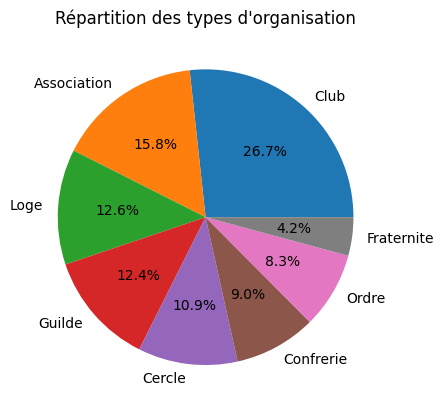

In [23]:
# Comptage du nombre d'organisation par type
counts = organisation["type_orga"].value_counts()

# Création du graphique en camembert, des part, du titre, affichage en pourcentage avec une décimale
# Sauvegarde de l'image au format png avec uen résolution de 150 dpi
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%")
ax.set_title("Répartition des types d'organisation")
plt.savefig("graphique2_types_organisation.png", dpi=150)

# Cellule stats organisations par type
orga_par_type = organisation.groupby("type_orga").size()
print(orga_par_type.describe())

# Affichage du graphique
plt.show()

In [ ]:
Il y a une dominance des clubs parmis les organisations, ceux-ci se trouvant dans les grandes villes, là om les tenracs se concentrent le plus.

count       9.000000
mean      555.555556
std       614.734518
min        43.000000
25%        88.000000
50%       397.000000
75%       597.000000
max      1789.000000
dtype: float64


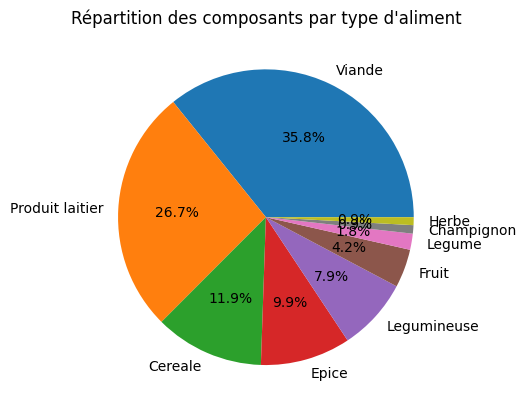

In [24]:
# Comptage du niombre de composants par type d'aliment
counts = composant["type_aliment"].value_counts()

# Création du graphique en camembert, des part, du titre, affichage en pourcentage avec une décimale
# Sauvegarde de l'image au format png avec uen résolution de 150 dpi
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%")
ax.set_title("Répartition des composants par type d'aliment")
plt.savefig("graphique3_types_aliment.png", dpi=150)

# Cellule stats composants par type
comp_par_type = composant.groupby("type_aliment").size()
print(comp_par_type.describe())

# Affichage du graphique
plt.show()

Le repas phare des tenracs étant les tenders à la raclette, on remarque une surreprésentation des produits laitiers et des viandes.
Ils en mangent effectivement d'autres, mais il y en a toujours à un repas. A l'inverse de la viande, les légumes sont plus "boudés" et ainsi bien plus rares.

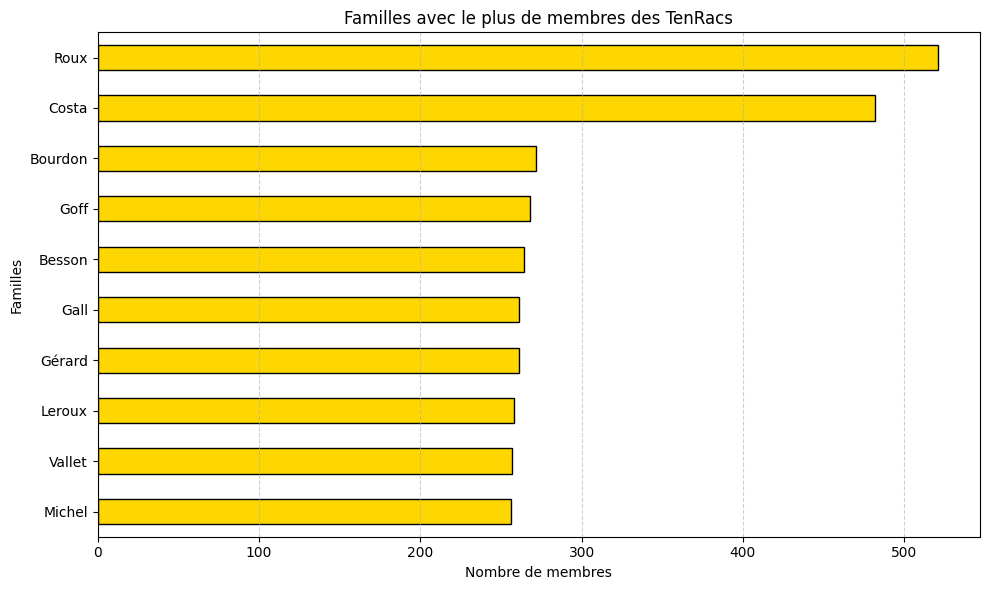

In [25]:
df = pd.read_csv('faker_output_v3/Membre.csv')

# groupage par famille et on prend les 10 premiers
top_familles = df.groupby(df['nom_membre'].str.split().str[-1]).size().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_familles.plot(kind='barh', color='gold', edgecolor='black')

plt.title('Familles avec le plus de membres des TenRacs')
plt.xlabel('Nombre de membres')
plt.ylabel('Familles')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Même si les familles comptent en moyenne 10 membres, cela est dû aux familles dominantes qui font grimper les chiffres. En réalité, on remarque que la médiane du nombre de membres par famille est de seulement 1, traduisant une repartition réellement inégale et une vraie dominance de certaines familles.

In [7]:
df = pd.read_csv('faker_output_v3/Membre.csv')

df['famille'] = df['nom_membre'].str.split().str[-1]

effectifs_par_famille = df['famille'].value_counts()

# moyenne des membres par famille
moyenne_membres_famille = effectifs_par_famille.mean()

print(f"En moyenne, chaque famille compte {moyenne_membres_famille:.2f} membres.")

# maximum et minimum 
print(f"Famille avec le plus de membres: {effectifs_par_famille.max()} membres")
print(f"Famille le moins de membres : {effectifs_par_famille.min()} membre(s)")

print("\nFamilles dominantes :")
print(effectifs_par_famille.head(5))

En moyenne, chaque famille compte 10.18 membres.
Famille avec le plus de membres: 467 membres
Famille le moins de membres : 1 membre(s)

Familles dominantes :
famille
Roux       467
Costa      442
Raymond    276
Aubry      263
Blanc      259
Name: count, dtype: int64


In [8]:
df = pd.read_csv('faker_output_v3/Membre.csv')

# extraction de la ville (dernier mot de l'adresse)
df['famille'] = df['nom_membre'].str.split().str[-1]
effectifs_par_famille = df.groupby('famille').size()

# calcul de l'écart-type
ecart_type_famille = effectifs_par_famille.std()

print(f"Écart-type : {ecart_type_famille:.2f}")
print(f"En calculant le coefficient de variation on trouve 1,22%, on considère donc la répartition homogène.")

Écart-type : 44.73
En calculant le coefficient de variation on trouve 1,22%, on considère donc la répartition homogène.


In [9]:
df = pd.read_csv('faker_output_v3/Membre.csv')
df['famille'] = df['nom_membre'].str.split().str[-1]

effectifs = df.groupby('famille').size()

#  25%, 50% (médiane) et 75%
quartiles = effectifs.quantile([0.25, 0.5, 0.75])

print(f" 25% : {quartiles[0.25]}")
print(f"Médiane (50%) : {quartiles[0.50]}")
print(f" 75% : {quartiles[0.75]}")

 25% : 1.0
Médiane (50%) : 1.0
 75% : 1.0


count    53312.000000
mean         1.875750
std         10.809055
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        752.000000
dtype: float64
Max repas par membre : 752
1-10       53294
11-50          7
51-100         0
101-300        0
301-500        0
>500          11
Name: count, dtype: int64


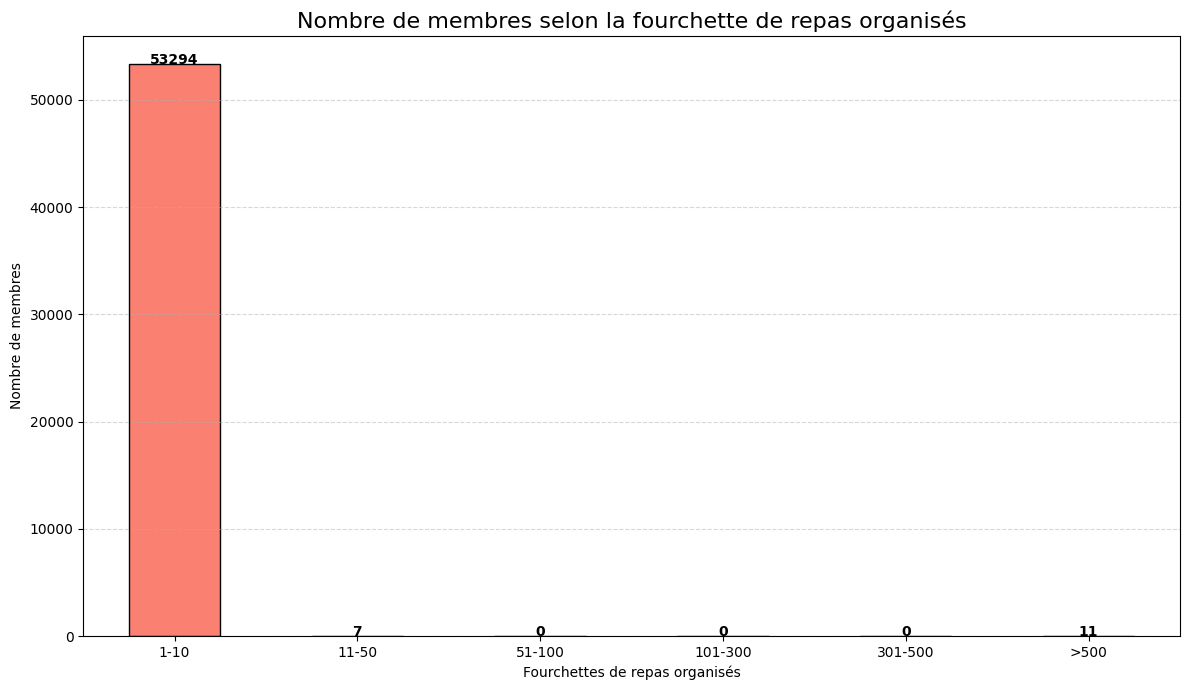

In [44]:
# --- Chargement des CSV ---
membre = pd.read_csv('faker_output_v3/Membre.csv', dtype={'CodeMembre': str})
est_organise = pd.read_csv('faker_output_v3/Est_organise.csv', dtype={'CodeMembre': str, 'IdR': str})

# --- Nettoyage des espaces invisibles ---
membre['CodeMembre'] = membre['CodeMembre'].str.strip()
membre['nom_membre'] = membre['nom_membre'].str.strip()
est_organise['CodeMembre'] = est_organise['CodeMembre'].str.strip()
est_organise['IdR'] = est_organise['IdR'].str.strip()

# --- Récupérer le nom du membre pour chaque repas ---
est_organise = est_organise.merge(
    membre[['CodeMembre', 'nom_membre']],
    on='CodeMembre',
    how='left'
)

# --- Nombre de repas par membre ---
repas_par_membre = est_organise.groupby('nom_membre').size()
repas_par_membre = repas_par_membre.astype(int)

# --- Vérification rapide ---
print(repas_par_membre.describe())
print("Max repas par membre :", repas_par_membre.max())

# --- Définition des fourchettes ---
bins = [0, 10, 50, 100, 300, 500, float('inf')]
labels = ['1-10', '11-50', '51-100', '101-300', '301-500', '>500']

# --- Classification des membres dans les fourchettes ---
fourchettes = pd.cut(repas_par_membre, bins=bins, labels=labels, right=True)
distribution = fourchettes.value_counts().sort_index()

print(distribution)  # vérification des counts

# --- Graphique ---
plt.figure(figsize=(12, 7))
distribution.plot(kind='bar', color='salmon', edgecolor='black')

# chiffres au-dessus des barres
for i, v in enumerate(distribution):
    plt.text(i, v + 2, str(int(v)), ha='center', fontweight='bold', fontsize=10)

plt.title("Nombre de membres selon la fourchette de repas organisés", fontsize=16)
plt.xlabel("Fourchettes de repas organisés")
plt.ylabel("Nombre de membres")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

On remarque une distribution très inégale des repas, là où la grande majorité des membres ont organisé 1 à 10 repas,
et la moitié d'entre eux moins de 2 repas, il y a une poignée de "super organsateurs" qui concentre à eux seuls plus de 5000 repas

La médiane est de : 185.5


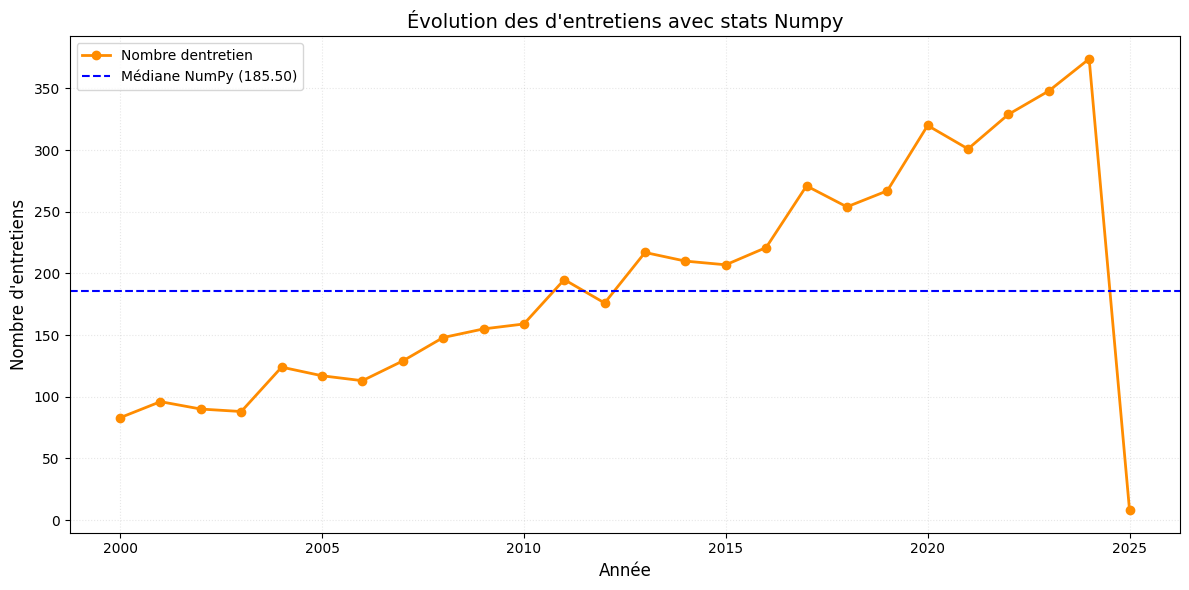

In [39]:
# 1. Chargement et préparation
entretien = pd.read_csv('faker_output_v3/Entretien.csv')
entretien['certificat_entretien'] = pd.to_datetime(entretien['certificat_entretien'])

# 2. Agrégation par année
evolution_entretiens = entretien.groupby(entretien['certificat_entretien'].dt.year)['IdE'].count()

# 3. Utilisation de NUMPY pour les statistiques
# On convertit les valeurs en array NumPy pour le calcul
valeurs = evolution_entretiens.values
mediane_np = np.median(valeurs)
moyenne_np = np.mean(valeurs) # Optionnel, pour la science !

print(f"La médiane est de : {mediane_np}")

# 4. Graphique
plt.figure(figsize=(12, 6))

# Courbe des entretiens
plt.plot(evolution_entretiens.index, valeurs, label='Nombre d''entretien', 
         marker='o', color='darkorange', linewidth=2)

# Ligne de la médiane via NumPy
plt.axhline(y=mediane_np, color='blue', linestyle='--', 
            label=f'Médiane NumPy ({mediane_np:.2f})')

# Personnalisation
plt.title("Évolution des d'entretiens avec stats Numpy", fontsize=14)
plt.xlabel('Année', fontsize=12)
plt.ylabel("Nombre d'entretiens", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On remarque une augmentation des entretiens des machines à travers les années, avec la médiane de l'évolution se trouvant aux alentours de 2012,
sois après 12 ans d'existence des tenracs, ce qui représente la moitié de celle-ci. 0 en 2025 car ils n'ont pas encore été enregistrés.

La médiane est de : 166.0


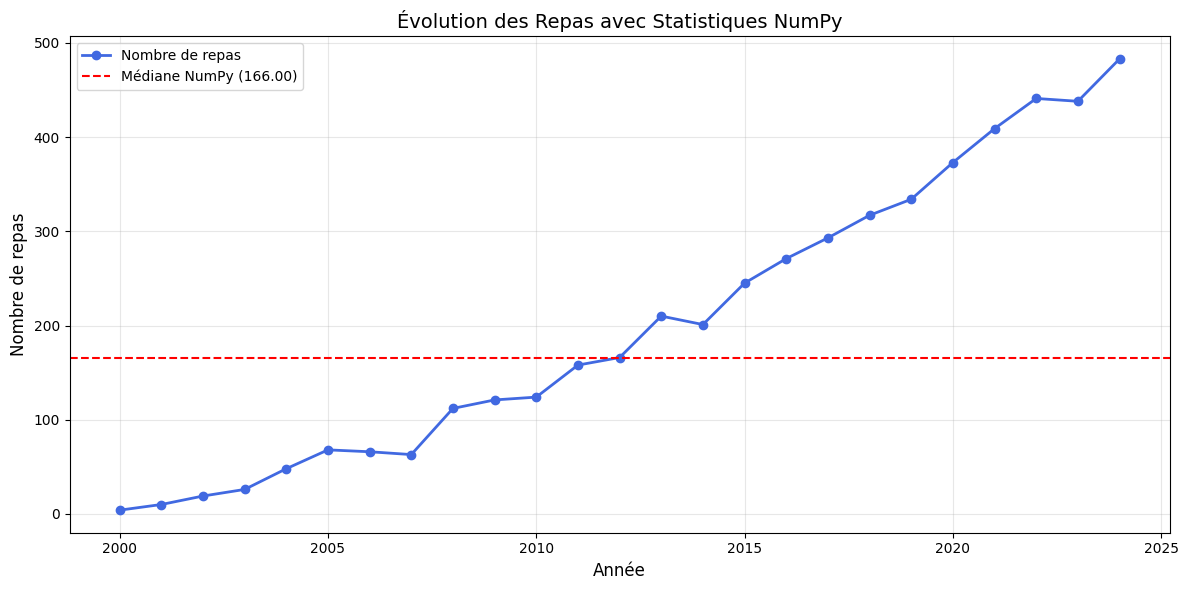

In [37]:

# 1. Chargement et préparation
repas = pd.read_csv('faker_output_v3/Repas.csv')
repas['date_repas'] = pd.to_datetime(repas['date_repas'])

# 2. Agrégation par année
evol_repas = repas.groupby(repas['date_repas'].dt.year)['IdR'].count()

# 3. Utilisation de NUMPY pour les statistiques
# On convertit les valeurs en array NumPy pour le calcul
valeurs = evol_repas.values
mediane_np = np.median(valeurs)
moyenne_np = np.mean(valeurs) # Optionnel, pour la science !

print(f"La médiane est de : {mediane_np}")

# 4. Graphique
plt.figure(figsize=(12, 6))

# Courbe des repas
plt.plot(evol_repas.index, valeurs, label='Nombre de repas', 
         marker='o', color='royalblue', linewidth=2)

# Ligne de la médiane via NumPy
plt.axhline(y=mediane_np, color='red', linestyle='--', 
            label=f'Médiane NumPy ({mediane_np:.2f})')

# Personnalisation
plt.title('Évolution des Repas avec Statistiques NumPy', fontsize=14)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Nombre de repas', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On remarque une augmentation des repas à travers les années, avec la médiane de l'évolution se trouvant aux alentours de 2012,
sois après 12 ans d'existence des tenracs, ce qui représente la moitié de celle-ci. 0 en 2025 car ils n'ont pas encore été enregistrés.

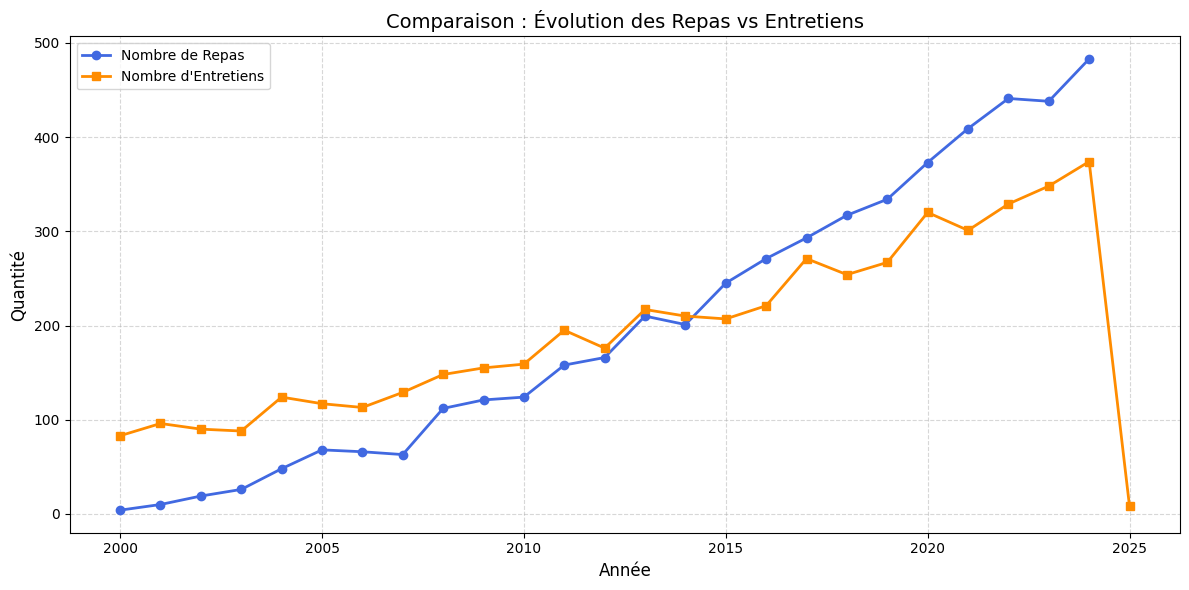

In [40]:
# 1. Chargement des deux fichiers
repas = pd.read_csv('faker_output_v3/Repas.csv')
entretien = pd.read_csv('faker_output_v3/Entretien.csv')

# 2. Préparation des dates
repas['date_repas'] = pd.to_datetime(repas['date_repas'])
entretien['certificat_entretien'] = pd.to_datetime(entretien['certificat_entretien'])

# 3. Agrégation par année
evol_repas = repas.groupby(repas['date_repas'].dt.year)['IdR'].count()
evol_entretiens = entretien.groupby(entretien['certificat_entretien'].dt.year)['IdE'].count()

# 4. Création du graphique comparatif
plt.figure(figsize=(12, 6))

# Tracé des deux courbes
plt.plot(evol_repas.index, evol_repas.values, label='Nombre de Repas', marker='o', color='royalblue', linewidth=2)
plt.plot(evol_entretiens.index, evol_entretiens.values, label="Nombre d'Entretiens", marker='s', color='darkorange', linewidth=2)

# Personnalisation
plt.title('Comparaison : Évolution des Repas vs Entretiens', fontsize=14)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Quantité', fontsize=12)
plt.legend() # Affiche la légende en haut à gauche par défaut
plt.grid(True, linestyle='--', alpha=0.5)

# Affichage
plt.tight_layout()
plt.show()

Les deux courbes ont tendance à grimper, et celle des entretiens suit celles de repas, on en déduit qu'après un repas s'en suit une série d'entretien 
des machines utilisés, généralement dans les 30 jours qui suivent.